# Descriptive Analytics for Numerical Columns

Load the Dataset

In [10]:
import pandas as pd

In [11]:
data= pd.read_csv(r'C:\Users\91962\OneDrive\Desktop\Basicstats-1\sales_data_with_discounts.csv')

# 1.Identify Numerical Columns

In [12]:
numerical_cols = data.select_dtypes(include=['number']).columns

In [13]:
print(numerical_cols)

Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')


Calculate Mean, Median, Mode, and Standard Deviation

In [14]:
mean_values = data[numerical_cols].mean()

In [15]:
print("Means:\n", mean_values)

Means:
 Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64


In [16]:
median_values = data[numerical_cols].median()

In [17]:
print("Medians:\n", median_values)

Medians:
 Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64


In [18]:
mode_values = data[numerical_cols].mode().iloc[0]

In [19]:
print("Modes:\n", mode_values)

Modes:
 Volume                   3.000000
Avg Price              400.000000
Total Sales Value    24300.000000
Discount Rate (%)        5.007822
Discount Amount         69.177942
Net Sales Value        326.974801
Name: 0, dtype: float64


In [20]:
std_dev_values = data[numerical_cols].std()

In [21]:
print("Standard Deviations:\n", std_dev_values)

Standard Deviations:
 Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64


#Interpretation

Mean: The average value of each numerical column.
Median: The middle value when data is sorted.
Mode: The most frequently occurring value.
Standard Deviation: The measure of the amount of variation or dispersion.

# 2.Data Visualization

Histograms

In [23]:
import matplotlib.pyplot as plt

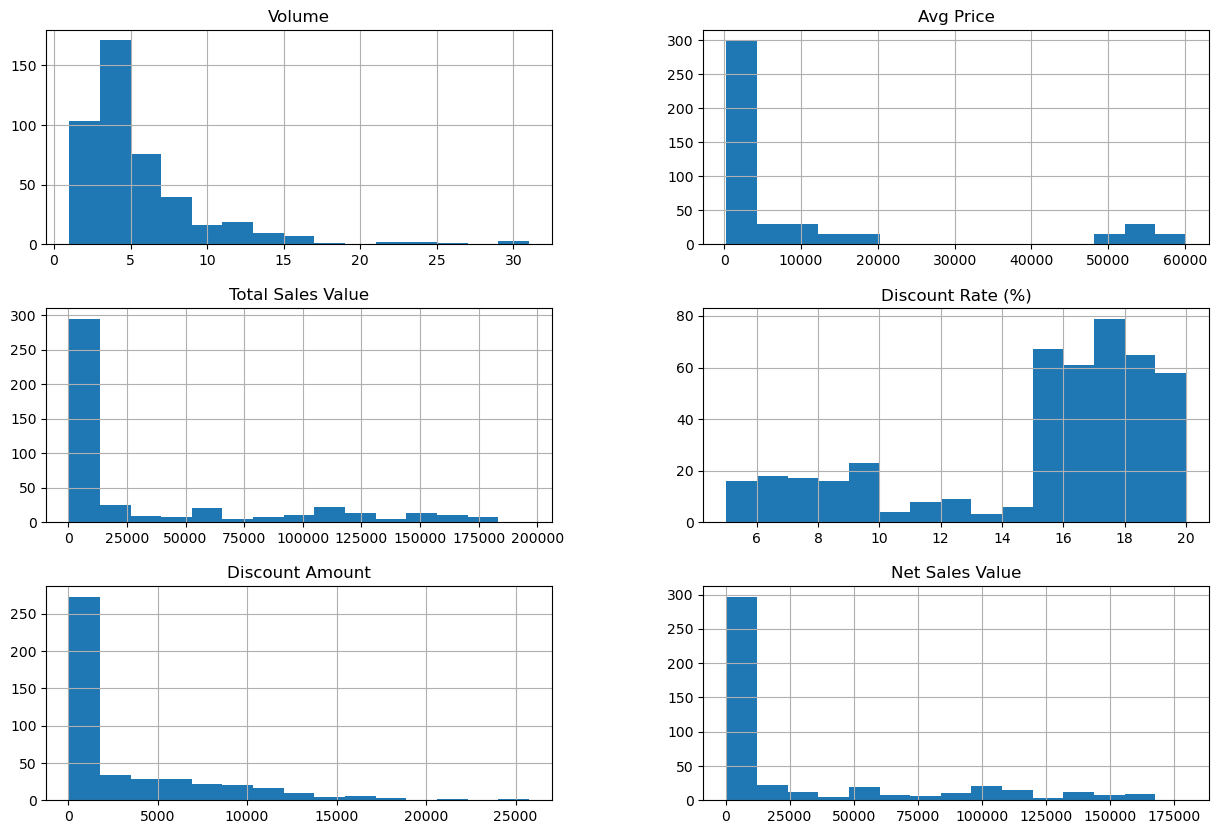

In [26]:
data[numerical_cols].hist(bins=15, figsize=(15, 10))
plt.show()

Interpretation

Analyze the shape, skewness, and outliers of the distributions.

Boxplots

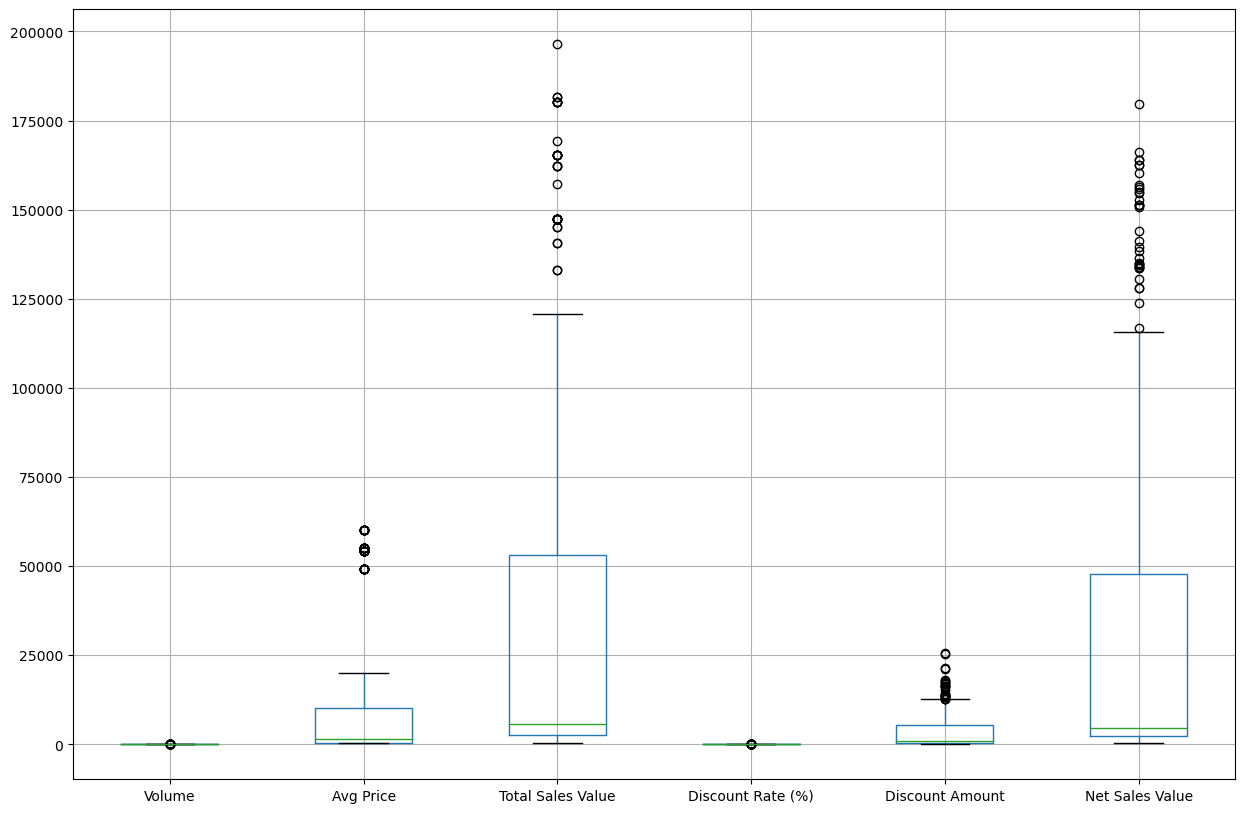

In [27]:
data[numerical_cols].boxplot(figsize=(15, 10))
plt.show()

Interpretation: Identify outliers and the interquartile range.

Bar Chart Analysis for Catergorical Column 

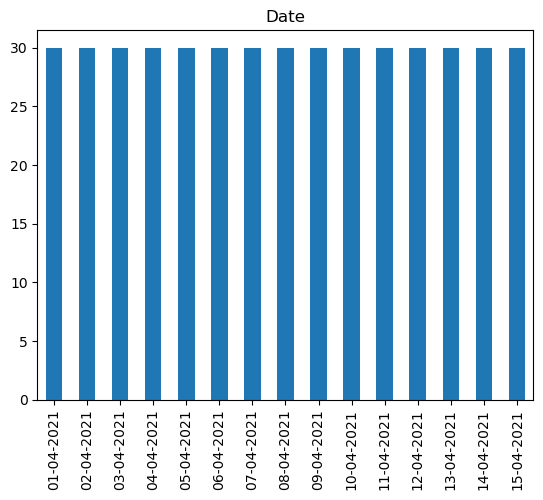

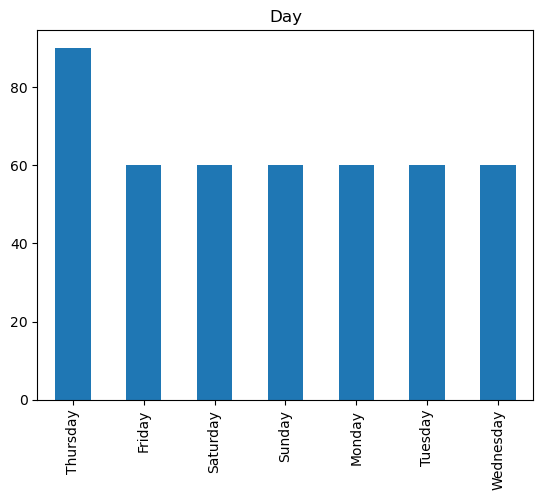

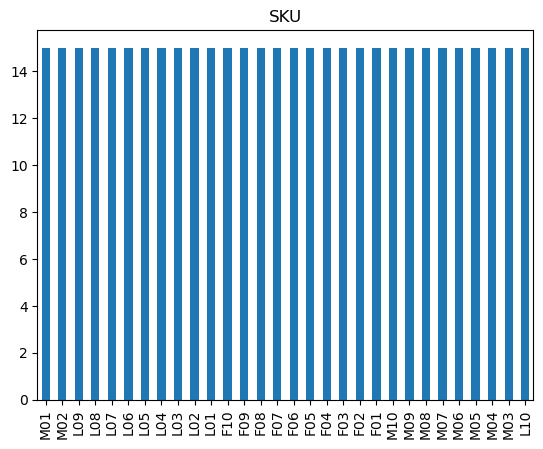

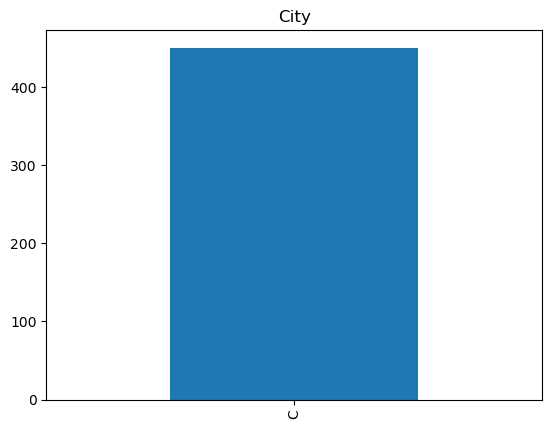

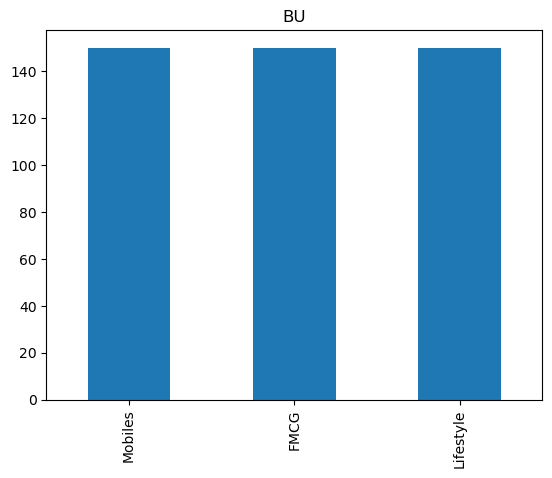

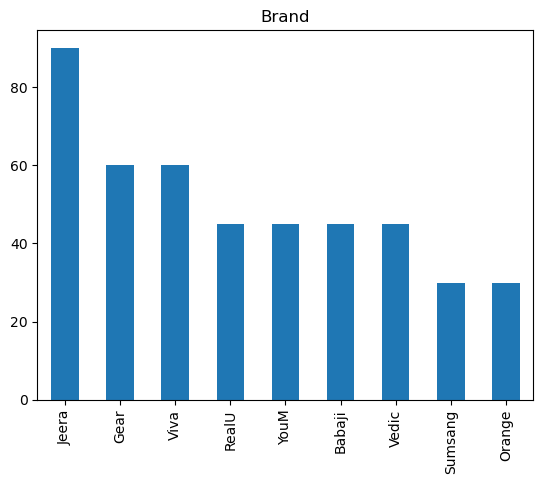

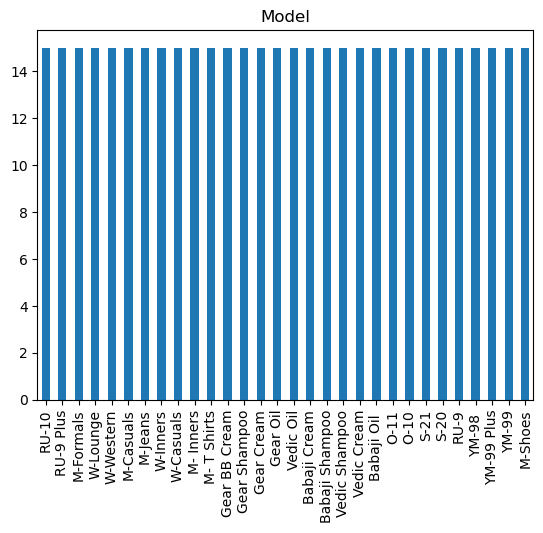

In [29]:
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

Interpretation: Analyze the frequency distribution of categories.

# 3.Standardization of Numerical Variables

Explanation of Standardization
Standardization: Scaling numerical values to have a mean of 0 and a standard deviation of 1 using the formula 
𝑧=𝑥−𝜇/𝜎

Standardize Numerical Columns

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_standardized = pd.DataFrame(scaler.fit_transform(data[numerical_cols]), columns=numerical_cols)

Before and After Comparisons

In [31]:
# Before Standardization
print(data[numerical_cols].describe())

# After Standardization
print(data_standardized.describe())


           Volume     Avg Price  Total Sales Value  Discount Rate (%)  \
count  450.000000    450.000000         450.000000         450.000000   
mean     5.066667  10453.433333       33812.835556          15.155242   
std      4.231602  18079.904840       50535.074173           4.220602   
min      1.000000    290.000000         400.000000           5.007822   
25%      3.000000    465.000000        2700.000000          13.965063   
50%      4.000000   1450.000000        5700.000000          16.577766   
75%      6.000000  10100.000000       53200.000000          18.114718   
max     31.000000  60100.000000      196400.000000          19.992407   

       Discount Amount  Net Sales Value  
count       450.000000       450.000000  
mean       3346.499424     30466.336131  
std        4509.902963     46358.656624  
min          69.177942       326.974801  
25%         460.459304      2202.208645  
50%         988.933733      4677.788059  
75%        5316.495427     47847.912852  
max   

# 4.Conversion of Categorical Data into Dummy Variables

Explanation of One-Hot Encoding
One-Hot Encoding: Transforming categorical variables into binary columns for each category.

Apply One-Hot Encoding

In [32]:
data_encoded = pd.get_dummies(data, columns=categorical_cols)
print(data_encoded.head())

   Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      15      12100             181500          11.654820     21153.498820   
1      10      10100             101000          11.560498     11676.102961   
2       7      16100             112700           9.456886     10657.910157   
3       6      20100             120600           6.935385      8364.074702   
4       3       8100              24300          17.995663      4372.946230   

   Net Sales Value  Date_01-04-2021  Date_02-04-2021  Date_03-04-2021  \
0    160346.501180                1                0                0   
1     89323.897039                1                0                0   
2    102042.089843                1                0                0   
3    112235.925298                1                0                0   
4     19927.053770                1                0                0   

   Date_04-04-2021  ...  Model_Vedic Cream  Model_Vedic Oil  \
0                0  ...

# 5.Conclusion

Summary of Key Findings

Descriptive Analytics
Mean: The mean provides an average value for each numerical column, which gives an overall sense of the central tendency of the data.

Median: The median represents the middle value in the dataset, providing insight into the data's central value without the influence of outliers.

Mode: The mode indicates the most frequently occurring value, which is particularly useful in identifying common trends or recurring values.

Standard Deviation: The standard deviation measures the spread of the data. A high standard deviation indicates that the data points are spread out over a larger range, while a low standard deviation indicates that they are closer to the mean.

Data Visualization

Histograms:

Shape and Skewness: Histograms help in identifying the shape of the data distribution (e.g., normal, skewed). For example, a right-skewed histogram indicates a long tail on the right side, which might suggest the presence of higher values or outliers.

Outliers: Histograms can show the presence of outliers by indicating data points that fall far from the main distribution.
Boxplots:

Interquartile Range (IQR): The boxplot shows the spread of the middle 50% of the data, giving insights into the variability within the dataset.

Outliers: Boxplots identify outliers as points outside the whiskers. These outliers can be critical in understanding unusual data points.
Bar Charts for Categorical Columns:

Category Frequency: Bar charts visualize the frequency of each category, highlighting the distribution of categorical data. This helps in understanding the prevalence of different categories within the dataset.

Reflection on Preprocessing Steps

Standardization of Numerical Variables
Importance: Standardization is crucial for ensuring that numerical features contribute equally to the analysis. It removes the bias that could result from features with different scales.


Method: Using z-score normalization (𝑧=𝑥−𝜇/𝜎) transforms the data to have a mean of 0 and a standard deviation of 1, making it suitable for algorithms sensitive to feature scaling, such as k-means clustering or principal component analysis (PCA).

Comparison: Before standardization, numerical features might dominate others due to their scale. After standardization, all features have a uniform scale, improving model performance and interpretability.
Conversion of Categorical Data into Dummy Variables

Importance: Many machine learning algorithms require numerical input. Converting categorical data into dummy variables (one-hot encoding) allows these algorithms to process categorical information effectively.

Method: One-hot encoding creates binary columns for each category, ensuring that the model can understand and utilize categorical information without assuming any ordinal relationship between categories.

Application: One-hot encoding is particularly important for algorithms like linear regression, decision trees, and neural networks, which can be biased by categorical features if not properly encoded.